# Проект на курсе Machine Learning (Магистратура)
---

**Состав команды:**
* Насиров Анар Чингиз оглы
* Журбинский Роман Игоревич
* Куготов Беслан Тимурович
* Домнина Анастасия Андреевна


**Датасет:** [eCommerce behavior data from multi category store](https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store)

**Объём данных:** This file contaisn behavior data for 7 months (from October 2019 to April 2020) from a large multi-category online store

**Признаки:** временная компонента `event_time`

**Основная задача:** Содержит поведение пользователей в интернет-магазине: просмотры, добавления в корзину, покупки, временные метки и категории товаров. Что можно предсказывать: например покупку или брошенную корзину

# Этап 1. Сбор команды, выбор датасета, EDA

## Описание датасета

Датасет представляет собой лог событий пользователей интернет-магазина, который содержит информацию о взаимодействиях с товарами (просмотр, добавление в корзину, удаление из корзины и покупка) с октября 2019 по апрель 2020. Каждое наблюдение описывает действие пользователя в определенный момент времени и содержит id пользователя, сессии и товара, а также характеристики товара (категория, бренд, цена).  
Датасет содержит данные о 285 млн пользователях.

## Задача проекта

## EDA

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'ramromazes'
os.environ['KAGGLE_KEY'] = 'KGAT_e867355134bdb8fa1abfd2937b1d32f7'

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d mkechinov/ecommerce-behavior-data-from-multi-category-store

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
License(s): copyright-authors
ecommerce-behavior-data-from-multi-category-store.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip ecommerce-behavior-data-from-multi-category-store.zip

Archive:  ecommerce-behavior-data-from-multi-category-store.zip
replace 2019-Nov.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: 2019-Nov.csv            y

replace 2019-Oct.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: 2019-Oct.csv            


In [ ]:
import pandas as pd
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [ ]:
df = pd.read_csv('2019-Oct.csv', )
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [ ]:
# !pip install pyspark

In [ ]:
# spark = SparkSession.builder \
#     .appName("ecommerce") \
#     .getOrCreate()

In [ ]:
# df_spark = spark.read.csv(
#     "2019-Oct.csv",
#     header=True,
#     inferSchema=True
# )

In [ ]:
# df_spark.show(5)

In [ ]:
n, m = df.shape
print(f'кол-во строк: {n}, кол-во столбцов: {m}')

кол-во строк: 42448764, кол-во столбцов: 9


In [ ]:
print('Уникальные значения в датасете')
df.nunique()

Уникальные значения в датасете


,0
event_time,2621538
event_type,3
product_id,166794
category_id,624
category_code,126
brand,3444
price,65298
user_id,3022290
user_session,9244421


In [ ]:
print('Типы действий пользователей')
print(df.event_type.unique())

Типы действий пользователей
['view' 'purchase' 'cart']


In [ ]:
print('Пустые значения в датасете')
df.isna().sum()

Пустые значения в датасете


,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,13515609
brand,6117080
price,0
user_id,0
user_session,2


Ограничиваем размер датафрейма для возможности работы в Google Colab  
Берем сэмпл по всем действиям рандомных 300 тысяч пользователей (5% пользователей)

In [ ]:
sample_users = df["user_id"].drop_duplicates().sample(300000)
df_sample = df[df["user_id"].isin(sample_users)]

In [ ]:
n_sample, m_sample = df_sample.shape
print(f'кол-во строк в сэмпле: {n_sample}, кол-во столбцов в сэмпле: {m_sample}')

кол-во строк в сэмпле: 4220119, кол-во столбцов в сэмпле: 9


In [ ]:
print(f'Размер сэмпла в %: {n_sample/n*100:.2f}')

Размер сэмпла в %: 9.94


In [ ]:
print('Уникальные значения в сэмпле датасета')
df_sample.nunique()

Уникальные значения в сэмпле датасета


,0
event_time,1887676
event_type,3
product_id,115584
category_id,617
category_code,126
brand,3063
price,45992
user_id,300000
user_session,917739


In [ ]:
print('Пустые значения в сэмпле датасета')
df_sample.isna().sum()

Пустые значения в сэмпле датасета


,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,1329566
brand,611773
price,0
user_id,0
user_session,0


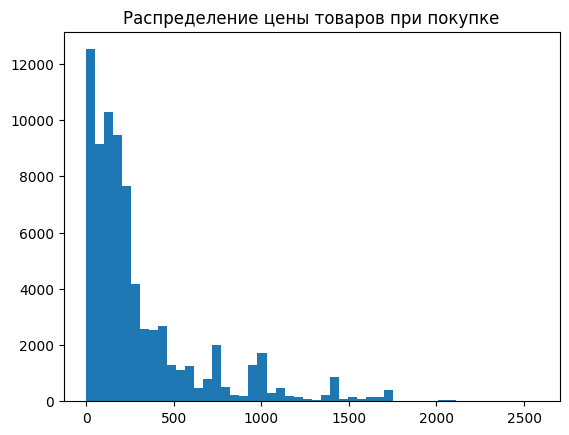

In [ ]:
plt.hist(df_sample[df_sample['event_type'] == 'purchase']['price'], bins=50)
plt.title('Распределение цены товаров при покупке')
plt.show()

In [ ]:
df_sample['day'] = pd.to_datetime(df_sample.loc[:,'event_time']).dt.date

df_sample['is_view'] = np.where(df_sample.loc[:,'event_type'] == 'view', 1, 0)
df_sample['is_purchase'] = np.where(df_sample.loc[:,'event_type'] == 'purchase', 1, 0)
df_sample['is_cart'] = np.where(df_sample.loc[:,'event_type'] == 'cart', 1, 0)

/tmp/ipykernel_35804/612990826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['day'] = pd.to_datetime(df_sample.loc[:,'event_time']).dt.date
/tmp/ipykernel_35804/612990826.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['is_view'] = np.where(df_sample.loc[:,'event_type'] == 'view', 1, 0)
/tmp/ipykernel_35804/612990826.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [ ]:
df_agg_day = (df_sample.groupby('day').
              agg(cnt_view=('is_view', 'sum'),
                  cnt_purchase=('is_purchase', 'sum'),
                  cnt_cart=('is_cart', 'sum'),
                  all_cnt=('user_session', 'count')).
              reset_index())

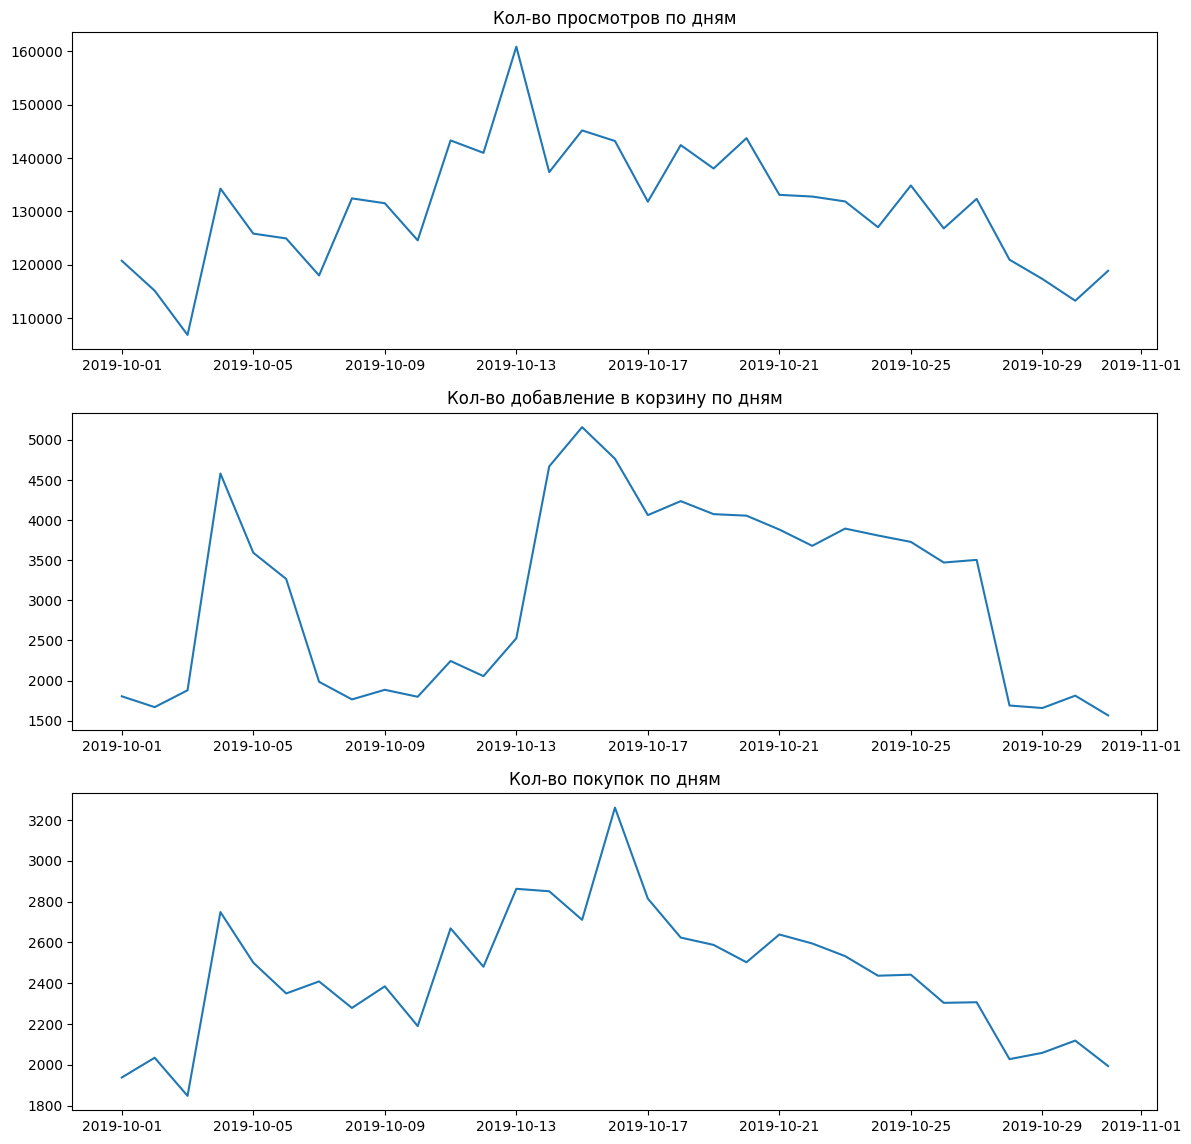

In [ ]:
fig, ax = plt.subplots(nrows=3, figsize=(14,14))

ax[0].plot(df_agg_day['day'], df_agg_day['cnt_view'])
ax[0].set_title('Кол-во просмотров по дням')

ax[1].plot(df_agg_day['day'], df_agg_day['cnt_cart'])
ax[1].set_title('Кол-во добавление в корзину по дням')

ax[2].plot(df_agg_day['day'], df_agg_day['cnt_purchase'])
ax[2].set_title('Кол-во покупок по дням')
plt.show()

In [ ]:
df_agg_day['view_to_cart'] = df_agg_day['cnt_cart'] / df_agg_day['cnt_view']
df_agg_day['cart_to_purchase'] = df_agg_day['cnt_purchase'] / df_agg_day['cnt_cart']

In [ ]:
mean_view_to_cart = df_agg_day['view_to_cart'].mean()
mean_cart_to_purchase = df_agg_day['cart_to_purchase'].mean()

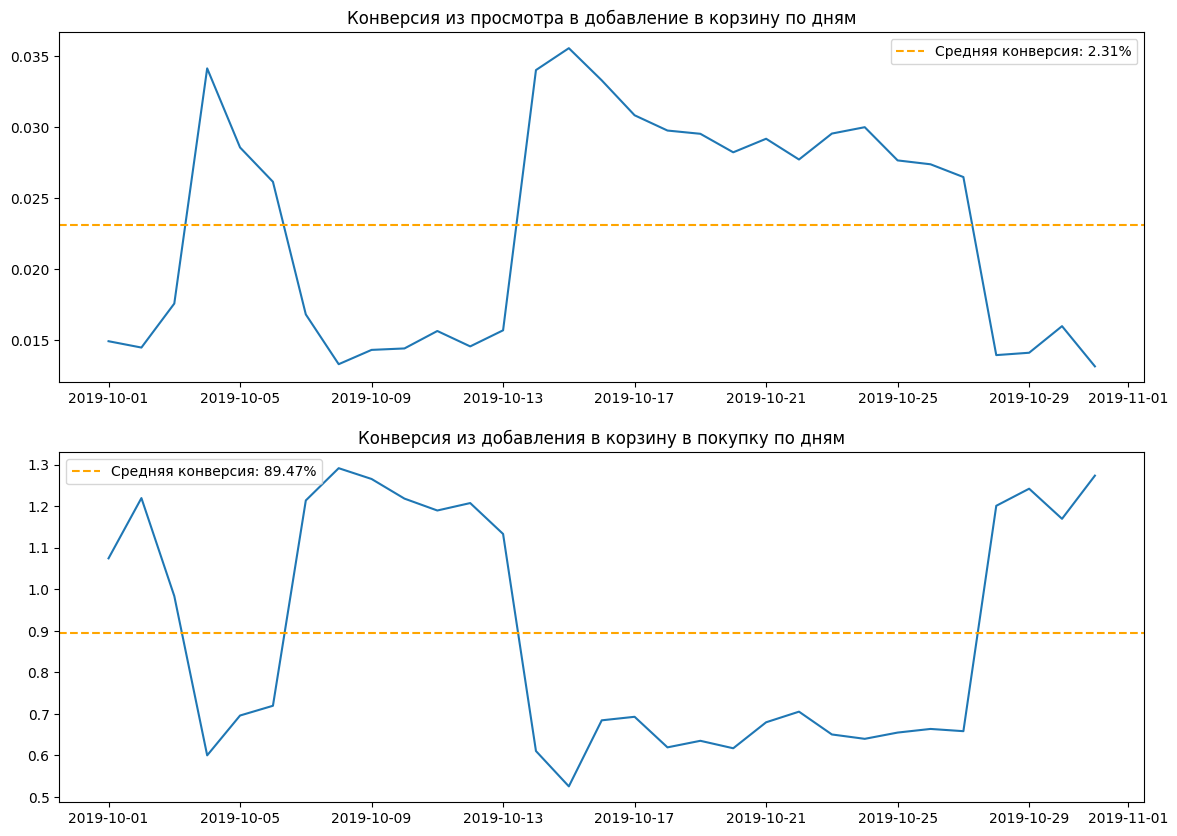

In [ ]:
fig, ax = plt.subplots(nrows=2, figsize=(14,10))

ax[0].plot(df_agg_day['day'], df_agg_day['view_to_cart'])
ax[0].axhline(mean_view_to_cart, color='orange', linestyle='--', label=f'Средняя конверсия: {mean_view_to_cart:.2%}')
ax[0].set_title('Конверсия из просмотра в добавление в корзину по дням')
ax[0].legend()

ax[1].plot(df_agg_day['day'], df_agg_day['cart_to_purchase'])
ax[1].axhline(mean_cart_to_purchase, color='orange', linestyle='--', label=f'Средняя конверсия: {mean_cart_to_purchase:.2%}')
ax[1].set_title('Конверсия из добавления в корзину в покупку по дням')
ax[1].legend()

plt.show()

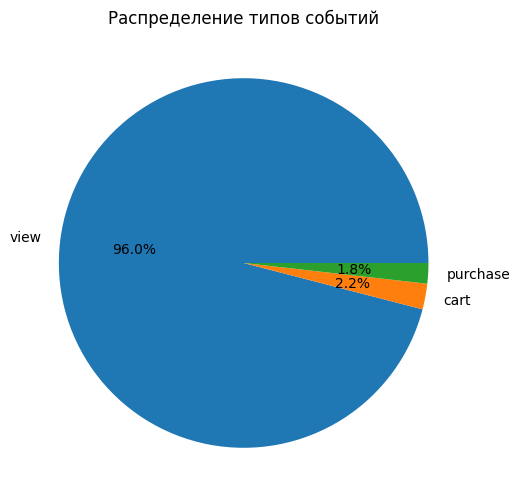

,count
event_type,
view,4049853
cart,94759
purchase,75507


In [ ]:
event_counts = df_sample['event_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%')
plt.title('Распределение типов событий')
plt.show()

event_counts

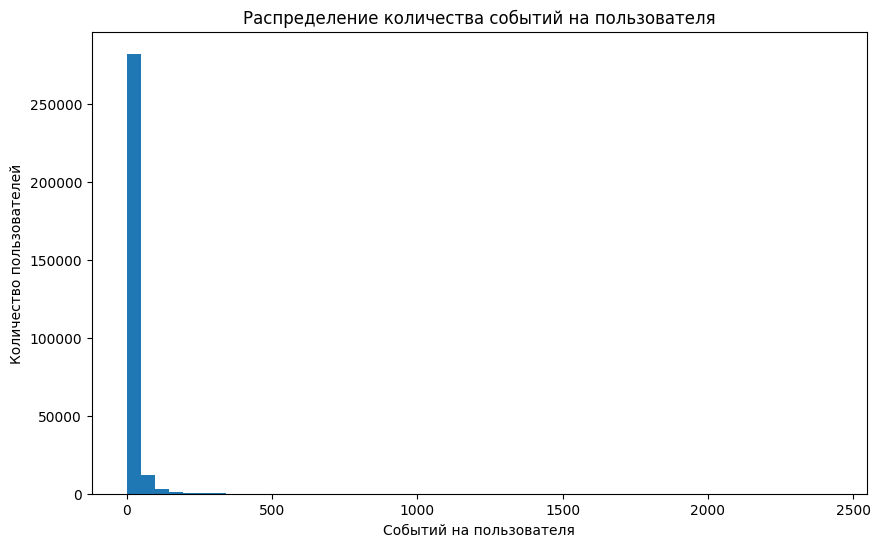

,0
count,300000.000000
mean,14.067063
std,32.814323
min,1.000000
25%,2.000000
50%,4.000000
75%,13.000000
max,2426.000000


In [ ]:
events_per_user = df_sample.groupby('user_id').size()

plt.figure(figsize=(10,6))
plt.hist(events_per_user, bins=50)
plt.title('Распределение количества событий на пользователя')
plt.xlabel('Событий на пользователя')
plt.ylabel('Количество пользователей')
plt.show()

events_per_user.describe()

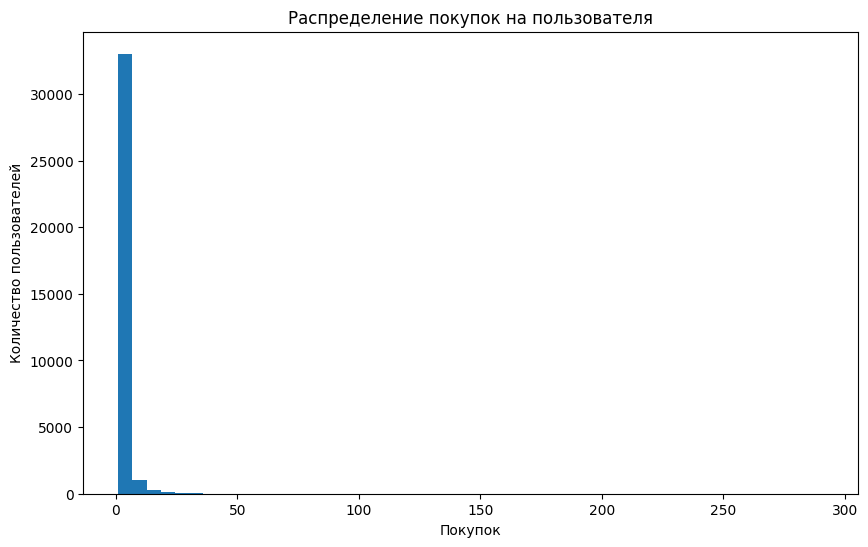

,0
count,34540.000000
mean,2.186074
std,4.317025
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,291.000000


In [ ]:
purchases = df_sample[df_sample['event_type'] == 'purchase']

purchases_per_user = purchases.groupby('user_id').size()

plt.figure(figsize=(10,6))
plt.hist(purchases_per_user, bins=50)
plt.title('Распределение покупок на пользователя')
plt.xlabel('Покупок')
plt.ylabel('Количество пользователей')
plt.show()
purchases_per_user.describe()

/tmp/ipykernel_35804/3382045722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['event_hour'] = pd.to_datetime(df_sample['event_time']).dt.hour


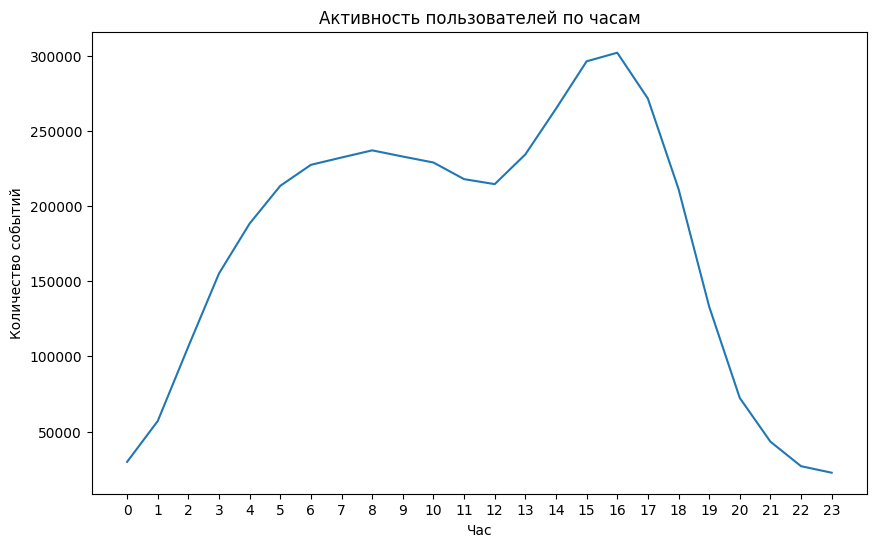

In [ ]:
df_sample['event_hour'] = pd.to_datetime(df_sample['event_time']).dt.hour

events_by_hour = df_sample.groupby('event_hour').size()

plt.figure(figsize=(10,6))
plt.plot(events_by_hour.index, events_by_hour.values)

plt.title('Активность пользователей по часам')
plt.xlabel('Час')
plt.ylabel('Количество событий')
plt.xticks(range(24))
plt.show()

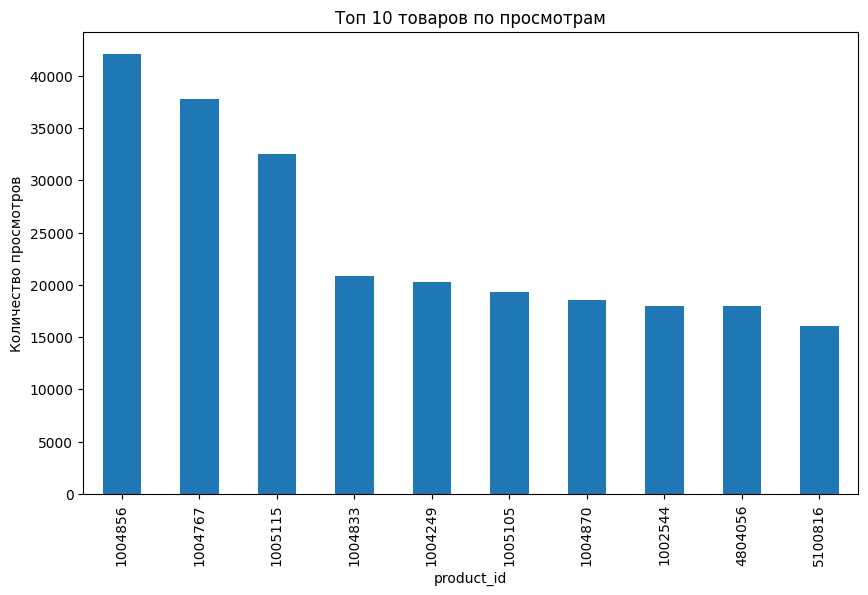

In [ ]:
top_products_view = (
    df_sample[df_sample['event_type']=='view']
    .groupby('product_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products_view.plot(kind='bar')
plt.title('Топ 10 товаров по просмотрам')
plt.ylabel('Количество просмотров')
plt.show()

## Baseline

**Задача:** купит ли пользователь товар

In [ ]:
df_sample['target'] = (df_sample['event_type'] == 'purchase').astype(int)

features = df_sample.groupby(['user_id', 'product_id']).agg(
    price_mean=('price', 'mean'),
    price_max=('price', 'max'),
    cnt_events=('event_type', 'count'),
    cnt_view=('is_view', 'sum')
).reset_index()

target = df_sample.groupby(['user_id', 'product_id'])['target'].max().reset_index()
data = features.merge(target, on=['user_id', 'product_id'])

/tmp/ipykernel_35804/1554560136.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['target'] = (df_sample['event_type'] == 'purchase').astype(int)


In [ ]:
# views = df_sample[df_sample['event_type'] == 'view']
# purchases = df_sample[df_sample['event_type'] == 'purchase']

# target = (
#     views.merge(
#         purchases[['user_id', 'product_id']],
#         on=['user_id', 'product_id'],
#         how='left',
#         indicator=True
#     )
# )

# target['target'] = (target['_merge'] == 'both').astype(int)

# data = features.merge(target, on=['user_id', 'product_id'])

In [ ]:
X = data.drop(columns=['target', 'user_id', 'product_id'])
# X = pd.get_dummies(X)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict_proba(X_test)[:, 1]
print(f'Dummy ROC-AUC: {roc_auc_score(y_test, y_pred_dummy)}')

Dummy ROC-AUC: 0.5


In [ ]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]
print(f'LogReg ROC-AUC: {roc_auc_score(y_test, y_pred_lr)}')

LogReg ROC-AUC: 0.9963500035391284


In [ ]:
# Decision Tree

tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict_proba(X_test)[:, 1]
print(f'Tree ROC-AUC: {roc_auc_score(y_test, y_pred_tree)}')

Tree ROC-AUC: 0.9945068135491634


In [ ]:
# Random Forest

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict_proba(X_test)[:, 1]
print(f'RF ROC-AUC: {roc_auc_score(y_test, y_pred_rf)}')

RF ROC-AUC: 0.9935677624595182


**Baseline модели**

В качестве базовых моделей были выбраны:
- DummyClassifier (наивный baseline)
- Logistic Regression
- Decision Tree
- Random Forest

В качестве метрики использовалась ROC-AUC, так как задача является задачей бинарной классификации с дисбалансом классов

**Результаты:**

In [ ]:
print('\t\tМодель | ROC-AUC')
print(f'\t\tDummy  | {roc_auc_score(y_test, y_pred_dummy)}')
print(f'   Logistic Regression | {roc_auc_score(y_test, y_pred_lr)}')
print(f'\t Decision Tree | {roc_auc_score(y_test, y_pred_tree)}')
print(f'\t Random Forest | {roc_auc_score(y_test, y_pred_rf)}')

		Модель | ROC-AUC
		Dummy  | 0.5
   Logistic Regression | 0.9963500035391284
	 Decision Tree | 0.9945068135491634
	 Random Forest | 0.9935677624595182


**Вывод:**

- DummyClassifier показывает случайный результат
- Линейная модель уже улавливает зависимости
- Деревья работают лучше за счёт нелинейностей
- Random Forest показывает лучший baseline

**Гипотезы:**

1. Пользователи, которые добавили товар в корзину, чаще покупают
2. Дешёвые товары покупают чаще
3. Некоторые категории имеют более высокую конверсию
4. Повторные пользователи покупают чаще

# Этап 2. Работа с аномалиями и генерация признаков

## Поиск аномалий

В этом блоке анализируются аномалии в данных интернет-магазина.

Аномалии рассматриваются на двух уровнях:

1. На уровне сырых событий. Здесь основной признак — `price`, так как цена в e-commerce часто имеет длинный правый хвост.
2. На уровне модельной таблицы `data`, где одна строка — это пара `user_id + product_id`.

Такой подход позволяет не просто найти выбросы, но и превратить их в новые признаки для ML-модели.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

pd.set_option('display.max_columns', 100)

In [ ]:
def get_iqr_bounds(series, k=1.5):
    clean = series.dropna().astype(float)
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return lower, upper, q1, q3, iqr


def get_z_scores(series):
    clean = series.astype(float)
    mean = clean.mean()
    std = clean.std(ddof=1)

    if std == 0 or np.isnan(std):
        return pd.Series(0, index=series.index), mean, std

    z = (clean - mean) / std
    return z, mean, std


def grubbs_test_outliers(series, alpha=0.05, max_outliers=30):
    x = series.dropna().astype(float)
    x = x[np.isfinite(x)]

    outlier_indices = []
    details = []

    while len(x) >= 3 and len(outlier_indices) < max_outliers:
        n = len(x)
        mean = x.mean()
        std = x.std(ddof=1)

        if std == 0 or np.isnan(std):
            break

        abs_diff = (x - mean).abs()
        idx = abs_diff.idxmax()
        g_stat = abs_diff.loc[idx] / std

        t_crit = stats.t.ppf(1 - alpha / (2 * n), n - 2)
        g_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(
            t_crit ** 2 / (n - 2 + t_crit ** 2)
        )

        if g_stat > g_crit:
            outlier_indices.append(idx)
            details.append({
                'index': idx,
                'value': x.loc[idx],
                'G': g_stat,
                'G_critical': g_crit,
                'n_left': n
            })
            x = x.drop(index=idx)
        else:
            break

    return outlier_indices, pd.DataFrame(details)

### Статистические методы: Z-score, IQR и тест Граббса

Сначала анализируем признак `price`.

Цена выбрана не случайно:

- в интернет-магазинах цена обычно распределена неравномерно;
- большинство товаров стоит относительно недорого;
- небольшая часть товаров может быть очень дорогой;
- такие товары могут быть как реальными премиальными товарами, так и ошибками в данных.

Для IQR используем обычную цену.

Для Z-score смотрим и обычную цену, и `log1p(price)`, потому что логарифмирование уменьшает влияние длинного правого хвоста.

Для теста Граббса используем `log1p(price)`, так как этот тест лучше работает для распределений, близких к нормальному.

In [ ]:
price_check = df_sample[['user_id', 'product_id', 'event_type', 'price']].copy()
price_check = price_check.dropna(subset=['price'])
price_check = price_check[price_check['price'] >= 0].copy()

price_check['log_price'] = np.log1p(price_check['price'])

price_iqr_lower, price_iqr_upper, price_q1, price_q3, price_iqr = get_iqr_bounds(price_check['price'])

price_check['price_iqr_outlier'] = (
    (price_check['price'] < price_iqr_lower) |
    (price_check['price'] > price_iqr_upper)
).astype(int)

price_check['price_z'], price_mean, price_std = get_z_scores(price_check['price'])
price_check['price_z_outlier'] = (price_check['price_z'].abs() > 3).astype(int)

price_check['log_price_z'], log_price_mean, log_price_std = get_z_scores(price_check['log_price'])
price_check['log_price_z_outlier'] = (price_check['log_price_z'].abs() > 3).astype(int)

grubbs_idx, grubbs_details = grubbs_test_outliers(
    price_check['log_price'],
    alpha=0.05,
    max_outliers=30
)

price_check['price_grubbs_outlier'] = 0
price_check.loc[grubbs_idx, 'price_grubbs_outlier'] = 1

price_check['price_any_stat_outlier'] = (
    (price_check['price_iqr_outlier'] == 1) |
    (price_check['price_z_outlier'] == 1) |
    (price_check['log_price_z_outlier'] == 1) |
    (price_check['price_grubbs_outlier'] == 1)
).astype(int)

stat_price_summary = pd.DataFrame({
    'method': ['IQR', 'Z-score price', 'Z-score log_price', 'Grubbs log_price'],
    'n_outliers': [
        price_check['price_iqr_outlier'].sum(),
        price_check['price_z_outlier'].sum(),
        price_check['log_price_z_outlier'].sum(),
        price_check['price_grubbs_outlier'].sum()
    ]
})

stat_price_summary['share'] = stat_price_summary['n_outliers'] / len(price_check)

print('Границы IQR для price:')
print(f'Q1 = {price_q1:.2f}, Q3 = {price_q3:.2f}, IQR = {price_iqr:.2f}')
print(f'Нижняя граница = {price_iqr_lower:.2f}, верхняя граница = {price_iqr_upper:.2f}')

display(stat_price_summary)

price_check.sort_values('price', ascending=False).head(10)

Границы IQR для price:
Q1 = 66.67, Q3 = 358.57, IQR = 291.90
Нижняя граница = -371.18, верхняя граница = 796.42


,method,n_outliers,share
0,IQR,362922,0.085998
1,Z-score price,115355,0.027335
2,Z-score log_price,14500,0.003436
3,Grubbs log_price,0,0.000000


,user_id,product_id,event_type,price,log_price,price_iqr_outlier,price_z,price_z_outlier,log_price_z,log_price_z_outlier,price_grubbs_outlier,price_any_stat_outlier
7411689,516273679,21407288,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
6050235,515928444,21407287,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
17058833,559848958,21407287,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
36065192,561917651,21407288,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
35018626,519562051,21408156,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
28756590,514593172,21408154,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
28756133,514593172,21408156,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
34754872,514880418,21407287,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
34754685,514880418,21408165,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1
34751124,514880418,21408165,view,2574.07,7.853632,1,6.393551,1,2.313841,0,0,1


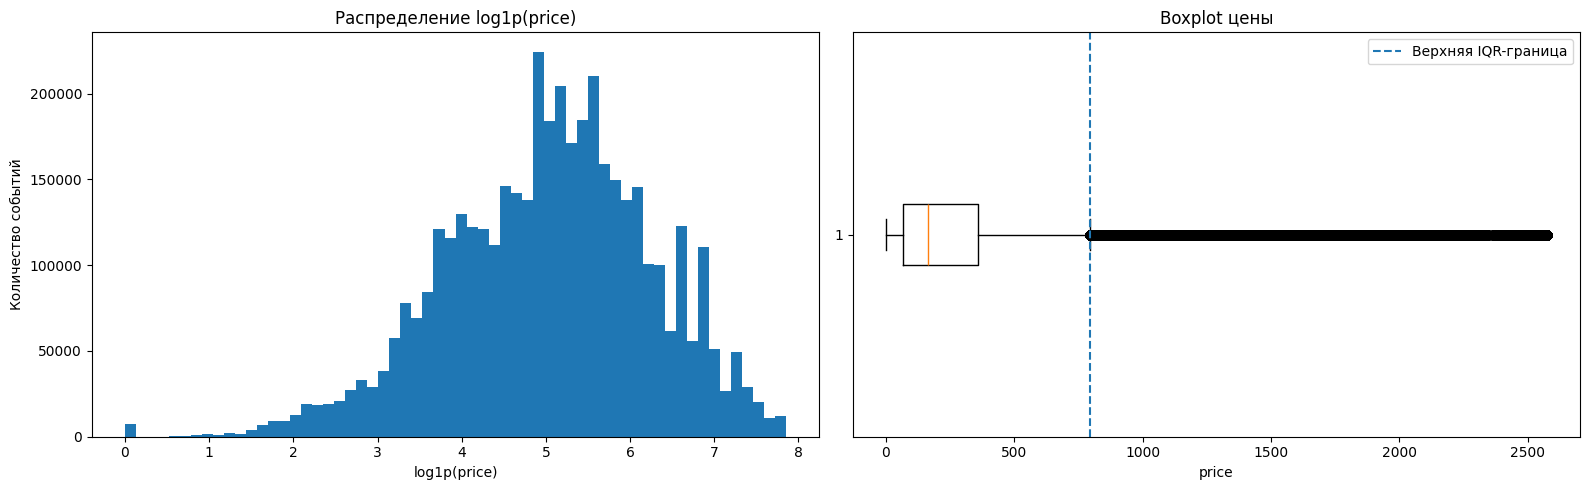

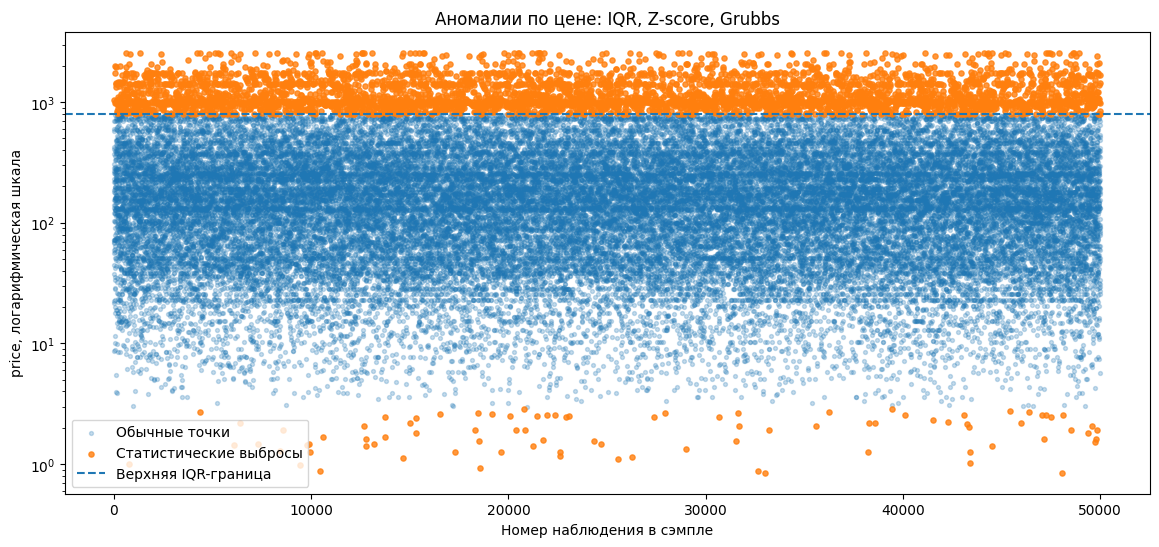

In [ ]:
plot_price = price_check.sample(
    n=min(50000, len(price_check)),
    random_state=42
).copy().reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].hist(np.log1p(price_check['price']), bins=60)
ax[0].set_title('Распределение log1p(price)')
ax[0].set_xlabel('log1p(price)')
ax[0].set_ylabel('Количество событий')

ax[1].boxplot(price_check['price'], vert=False, showfliers=True)
ax[1].axvline(price_iqr_upper, linestyle='--', label='Верхняя IQR-граница')
ax[1].set_title('Boxplot цены')
ax[1].set_xlabel('price')
ax[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

normal_points = plot_price[plot_price['price_any_stat_outlier'] == 0]
outlier_points = plot_price[plot_price['price_any_stat_outlier'] == 1]

plt.scatter(
    normal_points.index,
    normal_points['price'],
    s=8,
    alpha=0.25,
    label='Обычные точки'
)

plt.scatter(
    outlier_points.index,
    outlier_points['price'],
    s=14,
    alpha=0.8,
    label='Статистические выбросы'
)

plt.axhline(price_iqr_upper, linestyle='--', label='Верхняя IQR-граница')

plt.yscale('log')
plt.title('Аномалии по цене: IQR, Z-score, Grubbs')
plt.xlabel('Номер наблюдения в сэмпле')
plt.ylabel('price, логарифмическая шкала')
plt.legend()
plt.show()

#### Интерпретация статистических выбросов

По графикам видно, что распределение цены имеет длинный правый хвост. Это означает, что большинство событий связано с товарами обычной стоимости, но есть небольшая доля очень дорогих товаров.

Такие точки можно считать аномалиями по нескольким причинам:

1. По распределению  
   Значения находятся далеко за верхней IQR-границей и имеют высокий Z-score.

2. По бизнес-контексту  
   Очень дорогие товары в интернет-магазине могут быть реальными премиальными товарами. Например, техника, дорогая электроника или товары из специальных категорий.

3. По логике данных  
   Отрицательной цены быть не должно. Очень высокая цена не всегда ошибка, но её нужно дополнительно проверять по категории товара.


### Признаки на основе аномалий

Теперь превратим найденные аномалии в признаки для модели.

Идея такая: если пользователь взаимодействует с необычно дорогим товаром или очень много раз смотрит один и тот же товар, это может быть полезным сигналом для предсказания покупки.

Добавим:

- флаги выбросов по отдельным числовым признакам;
- счётчик количества аномальных признаков;
- общий флаг `any_stat_anomaly`.

In [ ]:
data_with_anomaly_features = data.copy()

stat_numeric_cols = [
    'price_mean',
    'price_max',
    'price_min',
    'price_std',
    'cnt_view',
    'n_sessions',
    'n_days',
    'first_event_hour',
    'last_event_hour'
]

stat_numeric_cols = [
    col for col in stat_numeric_cols
    if col in data_with_anomaly_features.columns
]

anomaly_feature_cols = []

for col in stat_numeric_cols:
    lower, upper, q1, q3, iqr = get_iqr_bounds(data_with_anomaly_features[col])

    iqr_flag = f'{col}_iqr_outlier'
    data_with_anomaly_features[iqr_flag] = (
        (data_with_anomaly_features[col] < lower) |
        (data_with_anomaly_features[col] > upper)
    ).astype(int)

    z, mean, std = get_z_scores(data_with_anomaly_features[col])

    z_flag = f'{col}_z_outlier'
    data_with_anomaly_features[z_flag] = (z.abs() > 3).astype(int)

    anomaly_feature_cols.extend([iqr_flag, z_flag])

data_with_anomaly_features['n_stat_anomalies'] = data_with_anomaly_features[anomaly_feature_cols].sum(axis=1)
data_with_anomaly_features['any_stat_anomaly'] = (
    data_with_anomaly_features['n_stat_anomalies'] > 0
).astype(int)

print('Добавлено статистических anomaly-признаков:', len(anomaly_feature_cols) + 2)

anomaly_summary = (
    data_with_anomaly_features[anomaly_feature_cols + ['any_stat_anomaly']]
    .mean()
    .sort_values(ascending=False)
    .to_frame('share_of_ones')
)

display(anomaly_summary.head(20))

data_with_anomaly_features.head()

Добавлено статистических anomaly-признаков: 8


,share_of_ones
any_stat_anomaly,0.161365
price_max_iqr_outlier,0.089979
price_mean_iqr_outlier,0.089870
cnt_view_iqr_outlier,0.076831
price_max_z_outlier,0.027650
price_mean_z_outlier,0.027443
cnt_view_z_outlier,0.016550


,user_id,product_id,price_mean,price_max,cnt_events,cnt_view,target,price_mean_iqr_outlier,price_mean_z_outlier,price_max_iqr_outlier,price_max_z_outlier,cnt_view_iqr_outlier,cnt_view_z_outlier,n_stat_anomalies,any_stat_anomaly
0,237271696,5100816,28.80,28.80,2,2,0,0,0,0,0,0,0,0,0
1,237271696,5100818,51.04,51.04,2,2,0,0,0,0,0,0,0,0,0
2,259515776,11600356,149.94,149.94,1,1,0,0,0,0,0,0,0,0,0
3,280403921,6400264,303.48,303.48,3,3,0,0,0,0,0,0,0,0,0
4,280403921,6400285,185.85,185.85,1,1,0,0,0,0,0,0,0,0,0


In [ ]:
anomaly_target_summary = (
    data_with_anomaly_features
    .groupby('any_stat_anomaly')
    .agg(
        objects=('target', 'count'),
        target_mean=('target', 'mean'),
        avg_price=('price_mean', 'mean'),
        avg_views=('cnt_view', 'mean'),
        avg_stat_anomalies=('n_stat_anomalies', 'mean')
    )
    .reset_index()
)

display(anomaly_target_summary)

,any_stat_anomaly,objects,target_mean,avg_price,avg_views,avg_stat_anomalies
0,0,1936990,0.012730,193.953809,1.363008,0.00000
1,1,372704,0.084214,799.412276,3.782412,2.03466


Если среднее значение `target` отличается между обычными и аномальными объектами, значит anomaly-признаки могут быть полезны для модели.

Например, если у аномальных объектов выше доля покупок, то необычное поведение пользователя может быть сигналом высокого интереса к товару.

Если ниже, то аномалии могут указывать на некачественный трафик, случайные просмотры или товары с низкой вероятностью покупки.

### ML-методы поиска сложных выбросов

Статистические методы анализируют признаки по отдельности.  
Но объект может быть аномальным не по одному признаку, а по сочетанию признаков.

Например:

- высокая цена;
- много просмотров;
- несколько сессий;
- необычное время активности.

Для поиска таких сложных выбросов используем:

1. Isolation Forest  
   Ищет объекты, которые легче всего изолировать от остальных.

2. LOF  
   Ищет объекты, которые находятся в областях с низкой локальной плотностью.

In [ ]:
ml_anomaly_cols = stat_numeric_cols + ['n_stat_anomalies', 'any_stat_anomaly']

X_anomaly = (
    data_with_anomaly_features[ml_anomaly_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

fit_idx = X_anomaly.sample(
    n=min(120000, len(X_anomaly)),
    random_state=42
).index

anomaly_scaler = StandardScaler()

X_fit_scaled = anomaly_scaler.fit_transform(X_anomaly.loc[fit_idx])
X_all_scaled = anomaly_scaler.transform(X_anomaly)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    max_samples=min(10000, len(fit_idx)),
    random_state=42,
    n_jobs=-1
)

iso.fit(X_fit_scaled)

data_with_anomaly_features['if_label'] = iso.predict(X_all_scaled)
data_with_anomaly_features['if_anomaly'] = (
    data_with_anomaly_features['if_label'] == -1
).astype(int)

data_with_anomaly_features['if_score'] = -iso.decision_function(X_all_scaled)

print('Доля аномалий по Isolation Forest:')
print(data_with_anomaly_features['if_anomaly'].value_counts(normalize=True))

display(
    data_with_anomaly_features
    .sort_values('if_score', ascending=False)
    [['user_id', 'product_id', 'target'] + ml_anomaly_cols + ['if_anomaly', 'if_score']]
    .head(10)
)

Доля аномалий по Isolation Forest:
if_anomaly
0    0.969942
1    0.030058
Name: proportion, dtype: float64


,user_id,product_id,target,price_mean,price_max,cnt_view,n_stat_anomalies,any_stat_anomaly,if_anomaly,if_score
11729,512372217,1005127,1,1657.820306,1671.83,93,6,1,1,0.258462
1937694,557234814,21409627,0,2162.220000,2162.22,35,6,1,1,0.255342
1730593,552053120,8500495,1,1595.758421,1595.79,56,6,1,1,0.252397
1978971,558009071,1005135,1,1722.846907,1747.73,45,6,1,1,0.249950
524819,515584613,2240053,1,2566.079615,2566.21,25,6,1,1,0.249916
116974,512786896,1307227,1,1887.050000,1887.05,36,6,1,1,0.249787
1051874,525987546,1005135,1,1738.926235,1747.79,43,6,1,1,0.249323
321935,513942842,1802045,1,1946.868936,2130.12,31,6,1,1,0.247024
276309,513630522,1801658,0,2574.040000,2574.04,22,6,1,1,0.245402
1414409,541663529,1005144,1,1747.790000,1747.79,38,6,1,1,0.244132


In [ ]:
compare_idx = X_anomaly.sample(
    n=min(50000, len(X_anomaly)),
    random_state=42
).index

X_compare_scaled = StandardScaler().fit_transform(X_anomaly.loc[compare_idx])

lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=0.03
)

lof_labels = lof.fit_predict(X_compare_scaled)

base_compare_cols = [
    'user_id',
    'product_id',
    'target',
    'any_stat_anomaly',
    'if_anomaly',
    'if_score'
]

compare_cols = base_compare_cols + ml_anomaly_cols

compare_cols = list(dict.fromkeys(compare_cols))

comparison = data_with_anomaly_features.loc[
    compare_idx,
    compare_cols
].copy()

comparison['lof_anomaly'] = (lof_labels == -1).astype(int)
comparison['lof_score'] = -lof.negative_outlier_factor_

print('Проверка дублей в колонках:')
print(comparison.columns[comparison.columns.duplicated()])

print('Сравнение Isolation Forest и LOF:')

display(
    pd.crosstab(
        comparison['if_anomaly'],
        comparison['lof_anomaly'],
        rownames=['Isolation Forest'],
        colnames=['LOF']
    )
)

method_compare = pd.DataFrame({
    'method': ['Statistical flags', 'Isolation Forest', 'LOF'],
    'share_anomalies': [
        comparison['any_stat_anomaly'].mean(),
        comparison['if_anomaly'].mean(),
        comparison['lof_anomaly'].mean()
    ],
    'target_mean_inside_anomalies': [
        comparison.loc[comparison['any_stat_anomaly'] == 1, 'target'].mean(),
        comparison.loc[comparison['if_anomaly'] == 1, 'target'].mean(),
        comparison.loc[comparison['lof_anomaly'] == 1, 'target'].mean()
    ]
})

display(method_compare)

Проверка дублей в колонках:
Index([], dtype='object')
Сравнение Isolation Forest и LOF:


LOF,0,1
Isolation Forest,,
0,46996,1496
1,1506,2


,method,share_anomalies,target_mean_inside_anomalies
0,Statistical flags,0.15954,0.081735
1,Isolation Forest,0.03016,0.127984
2,LOF,0.02996,0.006008


In [ ]:
y_weak = comparison['any_stat_anomaly'].astype(int)

metrics_rows = []

for method_col, score_col, method_name in [
    ('if_anomaly', 'if_score', 'Isolation Forest'),
    ('lof_anomaly', 'lof_score', 'LOF')
]:
    y_pred = comparison[method_col].astype(int)

    row = {
        'method': method_name,
        'precision_vs_stat_flags': precision_score(y_weak, y_pred, zero_division=0),
        'recall_vs_stat_flags': recall_score(y_weak, y_pred, zero_division=0),
        'f1_vs_stat_flags': f1_score(y_weak, y_pred, zero_division=0)
    }

    if y_weak.nunique() > 1:
        row['roc_auc_vs_stat_flags'] = roc_auc_score(y_weak, comparison[score_col])
    else:
        row['roc_auc_vs_stat_flags'] = np.nan

    metrics_rows.append(row)

display(pd.DataFrame(metrics_rows))

,method,precision_vs_stat_flags,recall_vs_stat_flags,f1_vs_stat_flags,roc_auc_vs_stat_flags
0,Isolation Forest,0.774536,0.146421,0.246284,0.87273
1,LOF,0.074099,0.013915,0.023430,0.48234


В датасете нет настоящей целевой метки "аномалия / не аномалия".  
Поэтому здесь используется слабая разметка: статистические флаги считаются приближённой меткой аномальности.

Это не абсолютная оценка качества, а способ сравнить, насколько ML-методы совпадают со статистическим подходом.

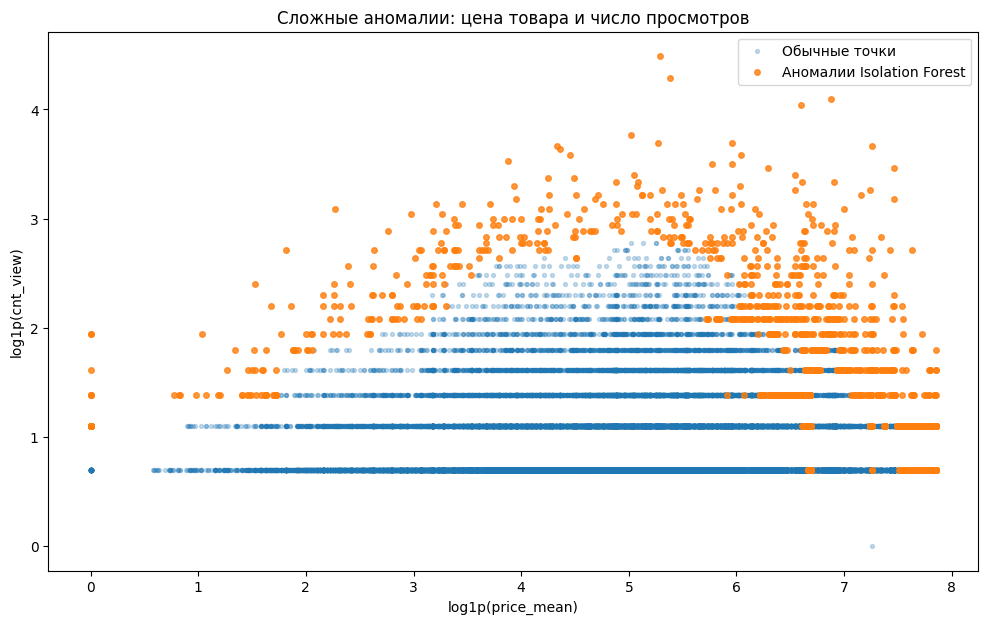

In [ ]:
viz = data_with_anomaly_features.sample(
    n=min(50000, len(data_with_anomaly_features)),
    random_state=42
).copy()

plt.figure(figsize=(12, 7))

normal = viz[viz['if_anomaly'] == 0]
anom = viz[viz['if_anomaly'] == 1]

plt.scatter(
    np.log1p(normal['price_mean']),
    np.log1p(normal['cnt_view']),
    s=8,
    alpha=0.25,
    label='Обычные точки'
)

plt.scatter(
    np.log1p(anom['price_mean']),
    np.log1p(anom['cnt_view']),
    s=16,
    alpha=0.8,
    label='Аномалии Isolation Forest'
)

plt.title('Сложные аномалии: цена товара и число просмотров')
plt.xlabel('log1p(price_mean)')
plt.ylabel('log1p(cnt_view)')
plt.legend()
plt.show()

#### Сравнение методов

IQR обычно находит больше выбросов, потому что хорошо реагирует на длинные хвосты распределения.

Z-score строже и сильнее зависит от среднего и стандартного отклонения. Для скошенной цены лучше использовать не только обычный `price`, но и `log1p(price)`.

Тест Граббса выделяет самые экстремальные одиночные точки. Его не стоит использовать как массовый фильтр для e-commerce-цен, потому что распределение цены не является нормальным.

Isolation Forest ищет не просто большие значения, а необычные комбинации признаков. Например, высокая цена плюс большое количество просмотров плюс несколько сессий.

LOF ищет точки с низкой локальной плотностью. Поэтому он может находить другие аномалии, чем Isolation Forest.

Стабильными можно считать точки, которые одновременно отмечены статистическими методами и ML-методами.

Расхождения между методами нормальны: статистические методы ловят одномерные выбросы, а ML-методы ловят необычные сочетания признаков.

### Проверка влияния anomaly-признаков на качество модели

Теперь сравним модель без anomaly-признаков и с ними.

Важно: `target` здесь означает покупку товара пользователем, а не настоящую метку аномалии.

Поэтому ROC-AUC и PR-AUC ниже показывают не качество поиска выбросов напрямую, а то, помогают ли признаки аномальности лучше предсказывать покупку.

In [ ]:
base_feature_cols = stat_numeric_cols

extra_anomaly_cols = (
    anomaly_feature_cols +
    ['n_stat_anomalies', 'any_stat_anomaly', 'if_anomaly', 'if_score']
)

extra_anomaly_cols = [
    col for col in extra_anomaly_cols
    if col in data_with_anomaly_features.columns
]

model_df = data_with_anomaly_features.sample(
    n=min(300000, len(data_with_anomaly_features)),
    random_state=42
).copy()

train_idx, test_idx = train_test_split(
    model_df.index,
    test_size=0.2,
    random_state=42,
    stratify=model_df['target']
)


def evaluate_rf(feature_cols, name):
    X_train_eval = (
        model_df.loc[train_idx, feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    X_test_eval = (
        model_df.loc[test_idx, feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    y_train_eval = model_df.loc[train_idx, 'target']
    y_test_eval = model_df.loc[test_idx, 'target']

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=30,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced_subsample'
    )

    model.fit(X_train_eval, y_train_eval)
    pred = model.predict_proba(X_test_eval)[:, 1]

    return {
        'model': name,
        'n_features': len(feature_cols),
        'roc_auc': roc_auc_score(y_test_eval, pred),
        'pr_auc': average_precision_score(y_test_eval, pred)
    }


results = []

results.append(
    evaluate_rf(
        base_feature_cols,
        'Random Forest без anomaly-признаков'
    )
)

results.append(
    evaluate_rf(
        base_feature_cols + extra_anomaly_cols,
        'Random Forest с anomaly-признаками'
    )
)

model_quality = pd.DataFrame(results)

display(model_quality)

delta_roc_auc = (
    model_quality.loc[
        model_quality['model'].str.contains('с anomaly'),
        'roc_auc'
    ].iloc[0]
    -
    model_quality.loc[
        model_quality['model'].str.contains('без anomaly'),
        'roc_auc'
    ].iloc[0]
)

print(f'Изменение ROC-AUC после добавления anomaly-признаков: {delta_roc_auc:.4f}')

,model,n_features,roc_auc,pr_auc
0,Random Forest без anomaly-признаков,3,0.864259,0.198527
1,Random Forest с anomaly-признаками,13,0.863550,0.206534


Изменение ROC-AUC после добавления anomaly-признаков: -0.0007


### Итоговое решение по аномалиям

По результатам анализа автоматически удалять все аномалии не стоит.

Причина в том, что для e-commerce необычные значения часто являются не ошибками, а важными бизнес-сигналами. Например, дорогой товар может быть реальным премиальным товаром, а большое число просмотров может показывать высокий интерес пользователя к покупке.

Что делаем с аномалиями:

1. Явные ошибки нужно очищать отдельно.  
   Например, отрицательная цена, пустой `user_id`, пустой `product_id` или невозможная дата — это проблемы качества данных.

2. Экстремальные, но логически возможные значения лучше оставить.  
   Высокая цена или большое количество просмотров могут быть полезны для анализа поведения пользователей.

3. Аномалии превращаем в признаки.  
   Для этого были добавлены:
   - флаги выбросов по отдельным признакам;
   - счётчик количества статистических аномалий;
   - общий флаг наличия аномалии;
   - флаг и anomaly-score из Isolation Forest.

4. Для устойчивости моделей можно дополнительно использовать логарифмирование цены.  
   Например, `log1p(price)` уменьшает влияние очень дорогих товаров и делает распределение более удобным для анализа.


# Этап 3. Интерпретация и диагностика моделей

## Интерпретация моделей (SHAP + LIME)

### SHAP для Logistic Regression и Random Forest

In [ ]:
!pip install shap lime

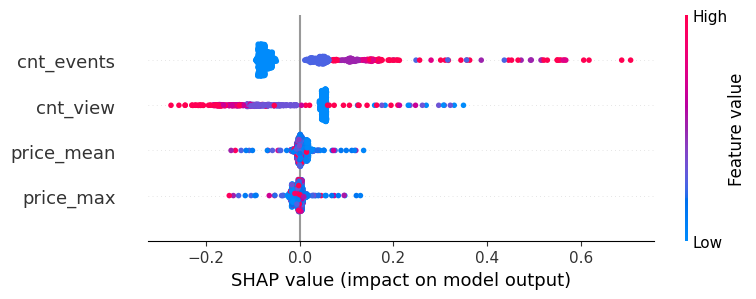

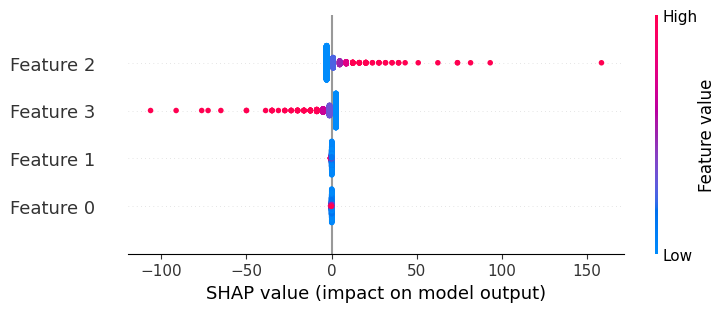

In [ ]:
import shap

# берём обученные модели
model_lr = lr
model_rf = rf

# RF
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)

explainer_rf = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf(X_sample)

shap_values_class1 = shap_values_rf[:, :, 1]

shap.summary_plot(shap_values_class1, X_sample)
# shap.summary_plot(shap_values_rf[1], X_sample)


# LR
X_sample_scaled = scaler.transform(X_sample)

explainer_lr = shap.Explainer(model_lr, X_train_scaled)
shap_values_lr = explainer_lr(X_sample_scaled)

shap.plots.beeswarm(shap_values_lr)

### Сравнение важности признаков

In [ ]:
# LR важности
lr_importance = np.abs(model_lr.coef_[0])
lr_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance_lr': lr_importance
}).sort_values('importance_lr', ascending=False)

# RF важности
rf_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance_rf': model_rf.feature_importances_
}).sort_values('importance_rf', ascending=False)

# объединяем
importance_compare = lr_imp_df.merge(rf_imp_df, on='feature')
print(importance_compare)

      feature  importance_lr  importance_rf
0  cnt_events       9.202191       0.414258
1    cnt_view       7.370909       0.353343
2   price_max       0.115994       0.113122
3  price_mean       0.092954       0.119277


### Локальная интерпретация (SHAP)

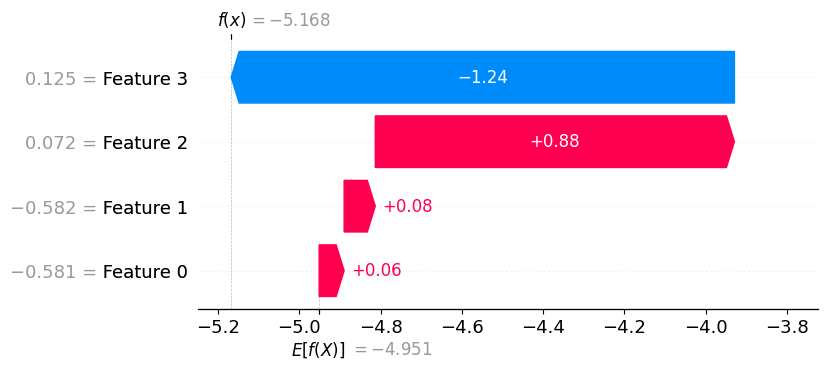

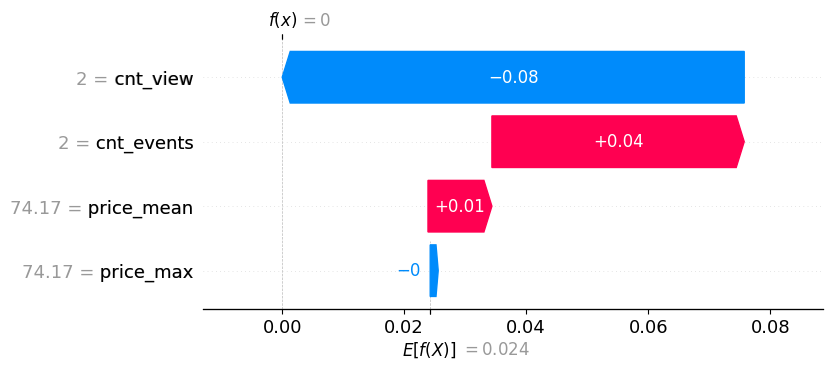

In [ ]:
i = 10

# --- Logistic Regression ---
if len(shap_values_lr.shape) == 3:
    shap.plots.waterfall(shap_values_lr[i, :, 0])
else:
    shap.plots.waterfall(shap_values_lr[i])


# --- Random Forest ---
if len(shap_values_rf.shape) == 3:
    shap.plots.waterfall(shap_values_rf[i, :, 1])
else:
    shap.plots.waterfall(shap_values_rf[i])

### LIME

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=['no_purchase', 'purchase'],
    mode='classification'
)

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    model_rf.predict_proba
)

exp.show_in_notebook()

## SHAP-эмбеддинги + сдвиги + кластеры

### Получаем SHAP embedding

In [ ]:
# берем RF (лучший baseline)
shap_emb = pd.DataFrame(
    shap_values_rf.values[:, :, 1],
    columns=X.columns
)

shap_emb.head()

,price_mean,price_max,cnt_events,cnt_view
0,-0.011405,-0.011075,0.076489,-0.078271
1,0.015630,-0.014204,-0.081233,0.055546
2,0.014041,-0.018825,-0.070871,0.051393
3,0.001864,0.005728,-0.086780,0.054927
4,0.006995,-0.016622,-0.064864,0.050229


### Поиск аномалий в SHAP-пространстве

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
shap_emb['anomaly'] = iso.fit_predict(shap_emb)

print(shap_emb['anomaly'].value_counts())

anomaly
 1    970
-1     30
Name: count, dtype: int64


### Удаление аномалий и переобучение

In [ ]:
mask = shap_emb['anomaly'] == 1

X_clean = X.loc[shap_emb.index[mask]]
y_clean = y.loc[shap_emb.index[mask]]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

rf_clean = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_clean.fit(X_train_c, y_train_c)

pred = rf_clean.predict_proba(X_test_c)[:,1]

print(f'ROC-AUC после очистки: {roc_auc_score(y_test_c, pred):.6f}')

ROC-AUC после очистки: 0.481865


### Кластеризация SHAP

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# уменьшаем размерность
pca = PCA(n_components=4)
shap_pca = pca.fit_transform(shap_emb.drop(columns=['anomaly']))

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(shap_pca)

shap_emb['cluster'] = clusters

### Визуализация

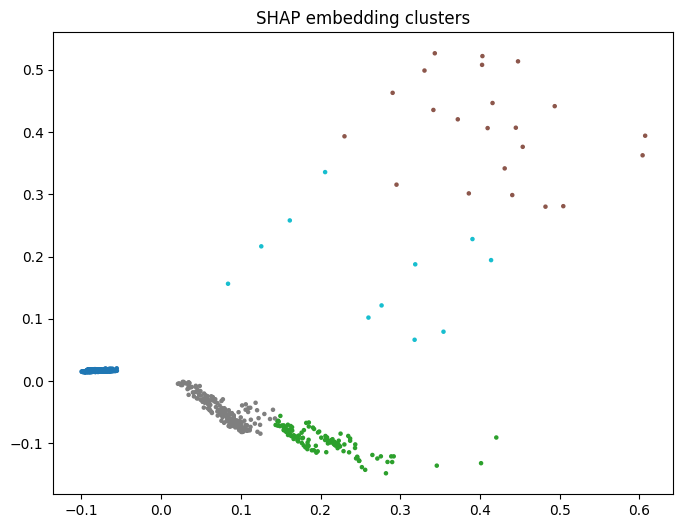

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(shap_pca[:,0], shap_pca[:,1], c=clusters, cmap='tab10', s=5)
plt.title('SHAP embedding clusters')
plt.show()

### Добавляем кластер как признак

In [ ]:
data_with_cluster = data.copy()
data_with_cluster['cluster'] = shap_emb['cluster']

X_cl = data_with_cluster.drop(columns=['target', 'user_id', 'product_id'])
y_cl = data_with_cluster['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_cl, y_cl, test_size=0.2, random_state=42, stratify=y_cl
)

rf_cluster = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_cluster.fit(X_train, y_train)

pred = rf_cluster.predict_proba(X_test)[:,1]

print(f'ROC-AUC с кластерами: {roc_auc_score(y_test, pred):.6f}')

ROC-AUC с кластерами: 0.993751


## Валидация + SHAP embeddings

### Только SHAP vs SHAP + признаки

In [ ]:
X_shap = shap_emb.drop(columns=['anomaly', 'cluster'], errors='ignore')

y_sample = y.loc[X_sample.index]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_shap, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

rf_shap = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_shap.fit(X_train_s, y_train_s)

pred = rf_shap.predict_proba(X_test_s)[:, 1]

print(f'ROC-AUC только SHAP: {roc_auc_score(y_test_s, pred):.6f}')

ROC-AUC только SHAP: 1.000000


In [ ]:
# конкатенация
X_combined = pd.concat([X.reset_index(drop=True), X_shap], axis=1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

rf_combined = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_combined.fit(X_train_c, y_train_c)

pred = rf_combined.predict_proba(X_test_c)[:,1]

print(f'ROC-AUC SHAP + признаки: {roc_auc_score(y_test_c, pred):.6f}')

ROC-AUC SHAP + признаки: 0.994093


### Shapley Flow

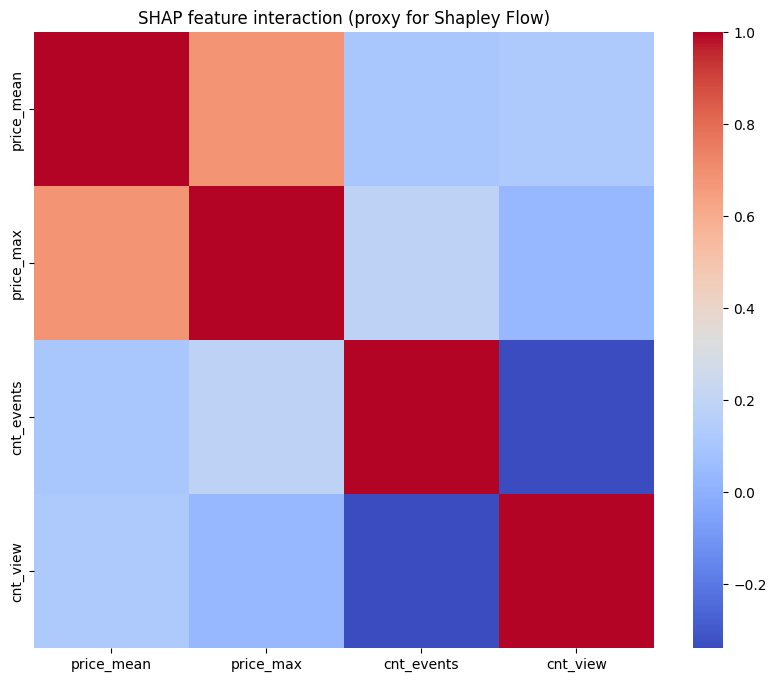

In [ ]:
import seaborn as sns

corr = shap_emb.drop(columns=['anomaly', 'cluster']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('SHAP feature interaction (proxy for Shapley Flow)')
plt.show()

## Вывод по этапу:

- изменился ли характер сдвига или аномалий

После перехода к SHAP-эмбеддингам характер аномалий изменился: вместо выбросов в исходных признаках выявляются объекты с аномальным вкладом признаков в предсказание модели


- изменилась ли структура кластеров

Кластеризация SHAP-эмбеддингов выявила группы объектов с различным поведением модели

Кластеры хорошо разделяют наблюдения по вероятности покупки


- удалось ли улучшить качество модели

Качество модели значительно выросло при использовании SHAP-признаков и кластеров

Однако значение ROC-AUC ~1.0 указывает на возможное переобучение или утечку таргета